# Detección de Anomalías en Transacciones con Tarjeta de Crédito
**Enfoque:** Aprendizaje no supervisado. Comparativa de candidatos ML (Isolation Forest, LOF, One-Class SVM) vs redes neuronales (Autoencoder, Denoising AE)  
**Evaluación:** split train/val/test; umbrales calibrados en validación; métricas finales en test

## 1. Introducción y Planteamiento del Problema

El fraude con tarjeta de crédito es un problema de alta relevancia en sistemas financieros: ocurre con baja frecuencia pero con consecuencias económicas significativas. El objetivo de este proyecto es construir un sistema capaz de detectar transacciones fraudulentas de forma automática.

### Tipo de aprendizaje

El enfoque adoptado es no supervisado. Los modelos se entrenan exclusivamente con transacciones legítimas y aprenden a representar el comportamiento normal. Una transacción se considera sospechosa cuando se desvía significativamente de ese comportamiento aprendido.

Se evalúan varios candidatos no supervisados y se elige el mejor en cada familia:

**Aprendizaje clásico (ML):**
- **Isolation Forest:** aislamiento aleatorio en árboles.
- **Local Outlier Factor (LOF):** anomalías por densidad local.
- **One-Class SVM:** frontera de decisión en espacio de características.

**Redes neuronales (NL):**
- **Autoencoder vanilla:** error de reconstrucción sobre transacciones normales.
- **Denoising Autoencoder:** variante con ruido gaussiano en entrenamiento para robustecer la representación.

La selección del modelo ganador usa **F1 y PR-AUC en validación** (umbral calibrado en val); las métricas reportadas en la sección 8 corresponden al **conjunto de test**, reservado hasta el final.
Se optó por aprendizaje no supervisado en lugar de clasificación supervisada por dos razones técnicas:

- **Desbalance extremo:** la proporción de transacciones fraudulentas es menor al 1%. Los clasificadores supervisados tienden a optimizar la clase mayoritaria, ignorando los fraudes.
- **Evolución del fraude:** los patrones de fraude cambian con el tiempo. Un modelo que aprende solo el comportamiento normal detecta cualquier desviación, incluyendo patrones de fraude nuevos no vistos en entrenamiento.

Las etiquetas de clase disponibles en el dataset (`is_fraud`) se reservan exclusivamente para evaluar el desempeño de los modelos, no para entrenarlos.

### Variables

- **Entrada:** características de la transacción derivadas del dataset. Las variables exactas que ingresan al modelo se definen en la sección 4, tras el análisis exploratorio y el preprocesamiento.
- **Salida (por modelo):** nivel de anomalía (un rango entre 0 y 1) y una etiqueta binaria (Normal / Anómalo).

## 2. Descripción del Dataset

El dataset utilizado es **Fraud_detection**, publicado en Kaggle por reemkasaab. Fue generado mediante la herramienta Sparkov Data Generation creada por Brandon Harris, que simula transacciones con tarjeta de crédito a partir de perfiles de comportamiento definidos por parámetros como frecuencia de transacciones, distribución de montos por categoría y patrones temporales.

El dataset cubre el período enero 2019 – diciembre 2020 e incluye transacciones simuladas de 1,000 clientes con 800 comerciantes distintos.

**Fuente:** https://www.kaggle.com/datasets/reemkasaab/fraud-detection  
**Licencia:** No especificada

Las dimensiones, distribución de clases, tipos de datos y valores nulos se verifican a continuación directamente sobre el archivo. El archivo cargado presenta 23 columnas: 22 variables del dataset más `Unnamed: 0`, que es el índice numérico del CSV original y no representa información del dominio.

In [1]:
from src.preprocessing import load_data, describe_dataset

df = load_data("data.csv")
describe_dataset(df)

Dimensiones: 1,852,394 filas × 23 columnas

Distribución de clases:
is_fraud
Normal    1842743
Fraude       9651
Name: count, dtype: int64

Porcentaje de fraude: 0.52%

Tipos de datos:
Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

Valores nulos:
Ninguno

Primeras filas:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0



Resumen estadístico (variables numéricas):


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1852394.0,5.371934e+05,3.669110e+05,0.000000e+00,2.315490e+05,4.630980e+05,8.335758e+05,1.296674e+06
cc_num,1852394.0,4.173860e+17,1.309115e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1852394.0,7.006357e+01,1.592540e+02,1.000000e+00,9.640000e+00,4.745000e+01,8.310000e+01,2.894890e+04
zip,1852394.0,4.881326e+04,2.688185e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.992100e+04
lat,1852394.0,3.853931e+01,5.071470e+00,2.002710e+01,3.466890e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1852394.0,-9.022783e+01,1.374789e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1852394.0,8.864367e+04,3.014876e+05,2.300000e+01,7.410000e+02,2.443000e+03,2.032800e+04,2.906700e+06
unix_time,1852394.0,1.358674e+09,1.819508e+07,1.325376e+09,1.343017e+09,1.357089e+09,1.374581e+09,1.388534e+09
merch_lat,1852394.0,3.853898e+01,5.105604e+00,1.902742e+01,3.474012e+01,3.936890e+01,4.195626e+01,6.751027e+01
merch_long,1852394.0,-9.022794e+01,1.375969e+01,-1.666716e+02,-9.689944e+01,-8.744069e+01,-8.024511e+01,-6.695090e+01


### Limitaciones del dataset

- **Naturaleza sintética:** generado por simulación, por lo que puede no cubrir todos los patrones reales de fraude.
- **Licencia no especificada:** limita su uso fuera del ámbito educativo y analítico.
- **Período acotado:** dos años de datos pueden introducir sesgo temporal si los patrones de fraude han cambiado.
- **Sin descripción oficial de columnas:** el dataset no incluye un diccionario de datos formal.

## 3. Análisis Exploratorio (EDA)

Antes de modelar, se exploran los patrones del dataset para entender la naturaleza de los datos y fundamentar las decisiones de preprocesamiento. El EDA busca responder cinco preguntas clave:

1. ¿Qué tan desbalanceado está el dataset?
2. ¿Los montos de transacciones fraudulentas difieren de las normales?
3. ¿Hay categorías de comercio con mayor incidencia de fraude?
4. ¿El fraude sigue patrones temporales (hora del día, día de la semana)?
5. ¿Existe diferencia en la tasa de fraude entre géneros?

In [2]:
from src.eda import (
    plot_class_distribution, plot_amount_by_class, plot_fraud_by_category,
    plot_time_patterns, plot_fraud_by_gender
)

Distribución de clases:
  Normal: 1,842,743 (99.48%)
  Fraude: 9,651 (0.52%)


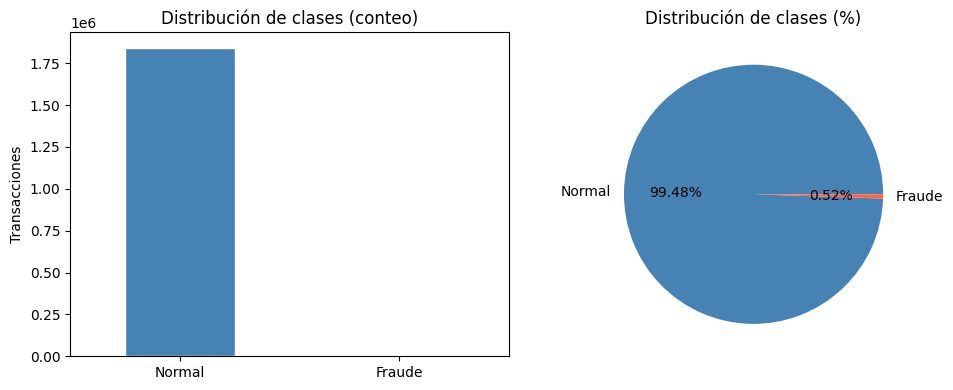

In [3]:
# 1. ¿Qué tan desbalanceado está el dataset?
plot_class_distribution(df)

El dataset presenta un desbalance extremo: el 99.48% de las transacciones son legítimas y apenas el 0.52% son fraudulentas. En el gráfico de barras la clase Fraude es prácticamente invisible, lo que ilustra visualmente por qué un clasificador supervisado entrenado sobre este dataset tendería a predecir siempre "Normal" y así alcanzar un 99.48% de exactitud, una métrica engañosa. Este desbalance es la motivación principal para adoptar un enfoque de detección de anomalías.

Estadísticas de monto por clase:
              count        mean         std   min      25%     50%      75%       max
is_fraud                                                                             
Normal    1842743.0   67.651278  153.548108  1.00    9.610   47.24   82.560  28948.90
Fraude       9651.0  530.661412  391.028873  1.06  240.075  390.00  902.365   1376.04


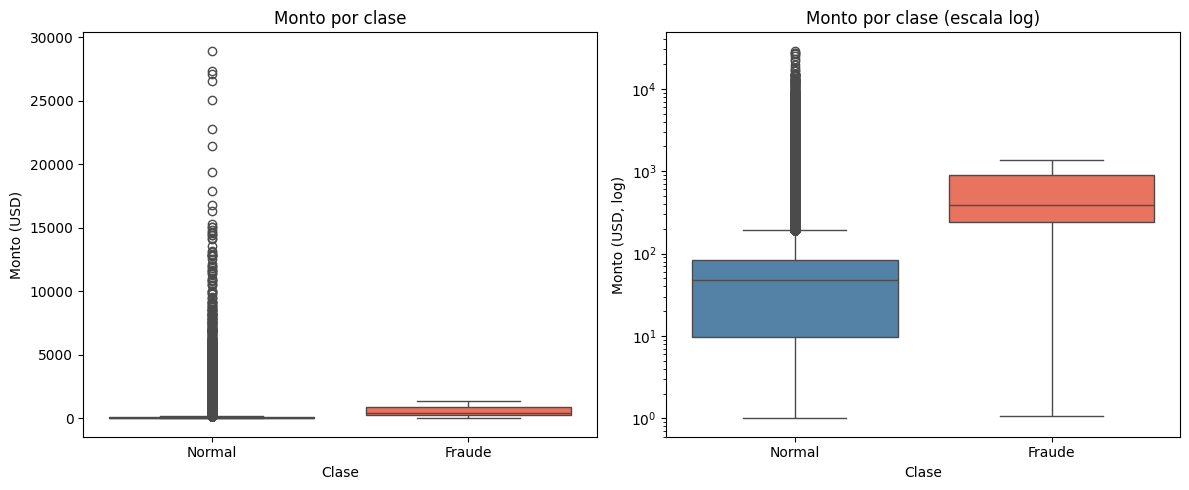

In [4]:
# 2. ¿Los montos de transacciones fraudulentas difieren de las normales?
plot_amount_by_class(df)

En escala lineal, los outliers de montos normales (hasta 28,948 dólares) dominan el eje y hacen que la caja de fraude sea casi invisible. Esto ilustra la necesidad de la escala logarítmica para analizar esta variable.

En escala logarítmica la diferencia es clara. La mediana de transacciones normales es 47.24 dólares, mientras que la de fraude es 390.00 dólares, aproximadamente 8 veces mayor. El 75% de las transacciones normales están por debajo de 82.56 dólares, valor que ni siquiera alcanza el percentil 25 del fraude (240.08 dólares). Esto significa que la gran mayoría de transacciones fraudulentas tienen montos superiores a casi toda la distribución normal.

Por otro lado, los valores más extremos del dataset (máximo 28,948 dólares) pertenecen a transacciones legítimas. El fraude tiene un máximo de 1,376.04 dólares, lo que indica que no apunta a montos máximos sino a un rango intermedio y acotado (240 a 902 dólares). El monto (`amt`) es una variable con poder discriminativo real y debe incluirse en el modelo.

Tasa de fraude por categoría (%):
category
shopping_net      1.59
misc_net          1.30
grocery_pos       1.26
shopping_pos      0.63
gas_transport     0.41
misc_pos          0.28
grocery_net       0.27
travel            0.27
personal_care     0.22
entertainment     0.22
kids_pets         0.19
food_dining       0.16
home              0.15
health_fitness    0.15


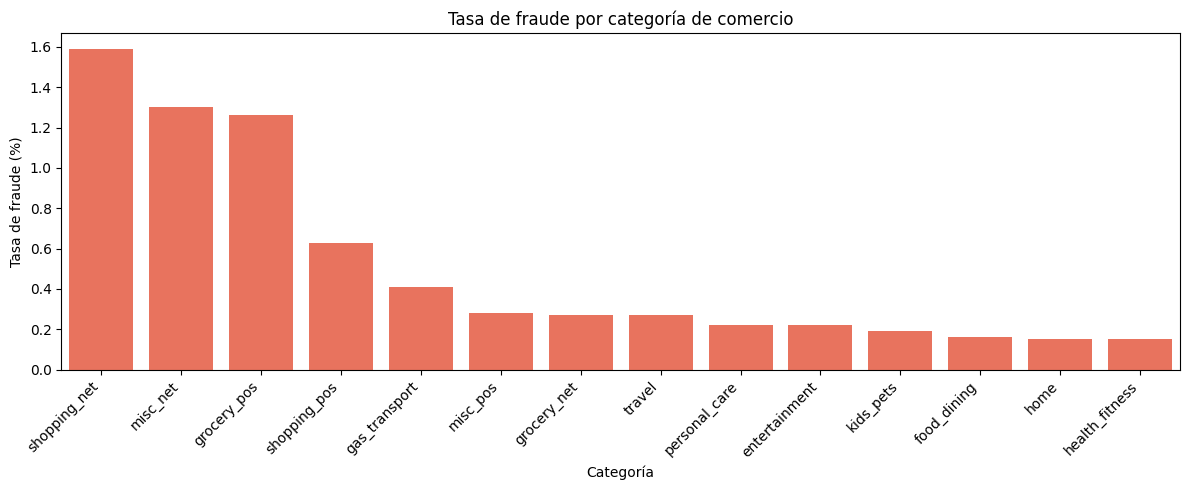

In [5]:
# 3. ¿Hay categorías de comercio con mayor incidencia de fraude?
plot_fraud_by_category(df)

La tasa de fraude varía significativamente entre categorías. `shopping_net` (compras minoristas en línea, 1.59%) tiene una tasa diez veces mayor que `home` y `health_fitness` (0.15%). Esa diferencia relativa entre categorías es lo que le da valor a esta variable para el modelo: no es que el fraude sea frecuente en términos absolutos, sino que la probabilidad de fraude cambia considerablemente dependiendo del tipo de comercio.

Dos de las tres categorías con mayor tasa son transacciones en línea (`shopping_net` y `misc_net`), lo que es coherente con que los canales digitales no requieren la presencia física de la tarjeta. La categoría (`category`) es una variable relevante para incluir en el modelo.

Tasa de fraude por hora:
hora
0     1.36
1     1.35
2     1.30
3     1.32
4     0.10
5     0.13
6     0.09
7     0.12
8     0.10
9     0.10
10    0.09
11    0.10
12    0.09
13    0.10
14    0.11
15    0.11
16    0.10
17    0.10
18    0.12
19    0.11
20    0.11
21    0.11
22    2.60
23    2.55

Tasa de fraude por día:
dia
Lunes        0.40
Martes       0.47
Miércoles    0.61
Jueves       0.64
Viernes      0.64
Sábado       0.57
Domingo      0.46


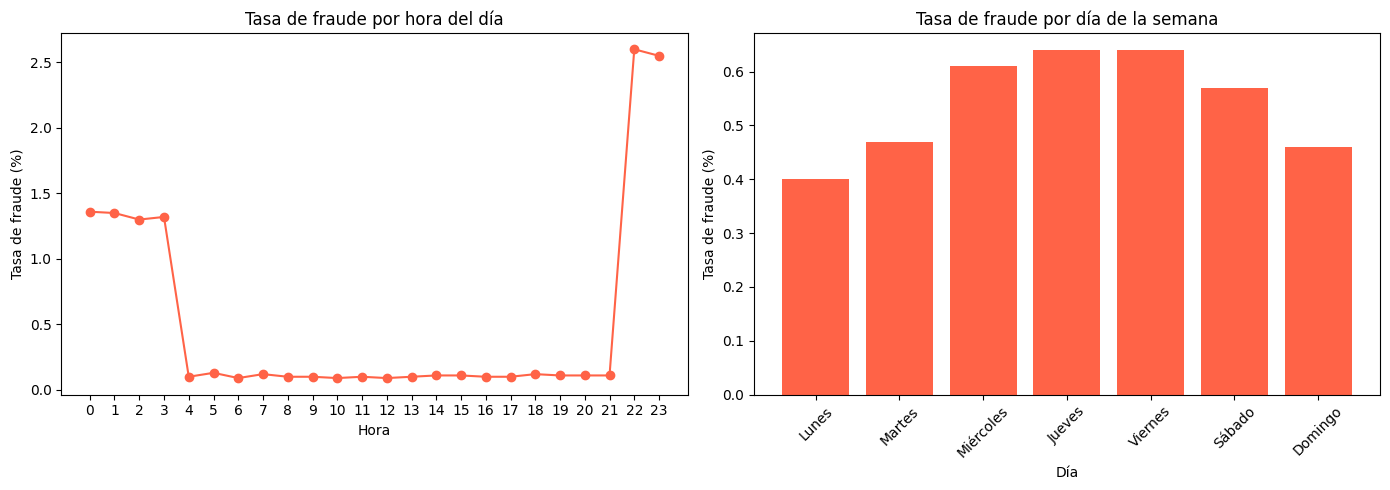

In [6]:
# 4. ¿El fraude sigue patrones temporales?
plot_time_patterns(df)

Las horas nocturnas (22:00, 23:00 y 0:00-3:00) concentran tasas entre 20 y 25 veces superiores al horario diurno. Esto sugiere que el fraude se ejecuta principalmente cuando los titulares están dormidos y es menos probable que reciban y reaccionen a alertas en tiempo real. La hora de la transacción es una variable con alto poder discriminativo y debe derivarse del campo `trans_date_trans_time` durante el preprocesamiento.

Por día de la semana la variación es menor y el patrón menos pronunciado, aunque sigue siendo una variable válida para incluir en el modelo.

Tasa de fraude por género:
   Género   Total  Fraudes  Tasa (%)
 Femenino 1014749     4899      0.48
Masculino  837645     4752      0.57


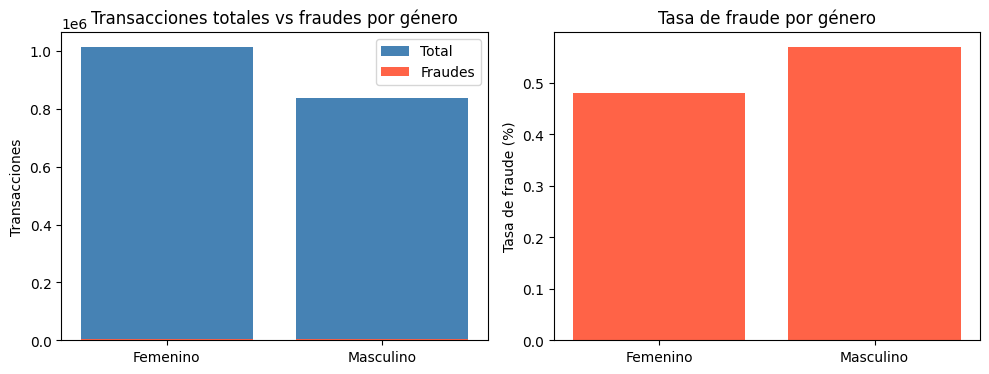

In [7]:
# 5. ¿Existe diferencia en la tasa de fraude entre géneros?
plot_fraud_by_gender(df)

La diferencia en la tasa de fraude entre géneros es mínima: 0.48% en transacciones de titulares femeninos y 0.57% en masculinos. A diferencia de la hora del día (diferencia de 20-25 veces) o la categoría del comercio (diferencia de 10 veces), el género aporta muy poco poder discriminativo al modelo.

Dado que la diferencia es marginal y que utilizar el género como variable predictiva introduce riesgos de sesgo de género, esta variable se descarta como entrada al modelo. Este punto se retoma en el análisis crítico.

## 4. Preprocesamiento

### Análisis de columnas numéricas

Min, max y rango por columna numérica:
                         min                          max                        rango
cc_num     60,416,207,185.00 4,992,346,398,065,154,048.00 4,992,346,337,648,947,200.00
unix_time   1,325,376,018.00             1,388,534,374.00                63,158,356.00
city_pop               23.00                 2,906,700.00                 2,906,677.00
Unnamed: 0              0.00                 1,296,674.00                 1,296,674.00
zip                 1,257.00                    99,921.00                    98,664.00
amt                     1.00                    28,948.90                    28,947.90
merch_long           -166.67                       -66.95                        99.72
long                 -165.67                       -67.95                        97.72
merch_lat              19.03                        67.51                        48.48
lat                    20.03                        66.69                        46.67
is_f

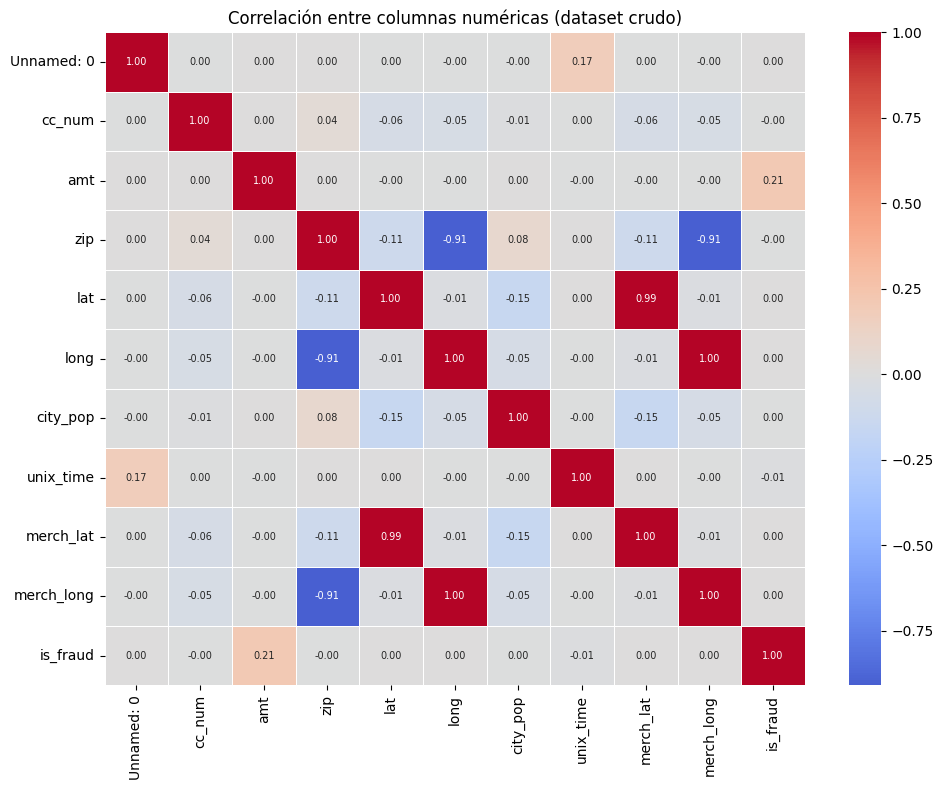

In [8]:
from src.eda import plot_numeric_analysis

plot_numeric_analysis(df)

La tabla de rangos y la matriz de correlación justifican qué columnas numéricas se eliminan:

**cc_num y Unnamed: 0:** rangos de 5×10¹⁸ y 1,296,674 respectivamente, confirman que son identificadores sin relación ordinal con el dominio. Se eliminan.

**unix_time:** correlaciona 0.17 con `Unnamed: 0`, lo que confirma su naturaleza de contador cronológico secuencial. La información temporal útil se extrae de `trans_date_trans_time` en el feature engineering. Se elimina.

**zip:** correlaciona -0.91 con `long` y -0.91 con `merch_long`. El código postal está prácticamente determinado por la longitud geográfica, por lo que no aporta información adicional a las coordenadas. Se elimina.

**Coordenadas (lat, long, merch_lat, merch_long):** `lat` y `merch_lat` correlacionan 0.99; `long` y `merch_long` correlacionan 1.00. Incluirlas por separado sería redundante. Se combinan en la variable `distancia` durante el feature engineering y luego se descartan.

### Análisis de columnas de texto

Cardinalidad de columnas de texto (valores únicos):
trans_num                1852394
trans_date_trans_time    1819551
street                       999
dob                          984
city                         906
merchant                     693
job                          497
last                         486
first                        355
state                         51
category                      14
gender                         2


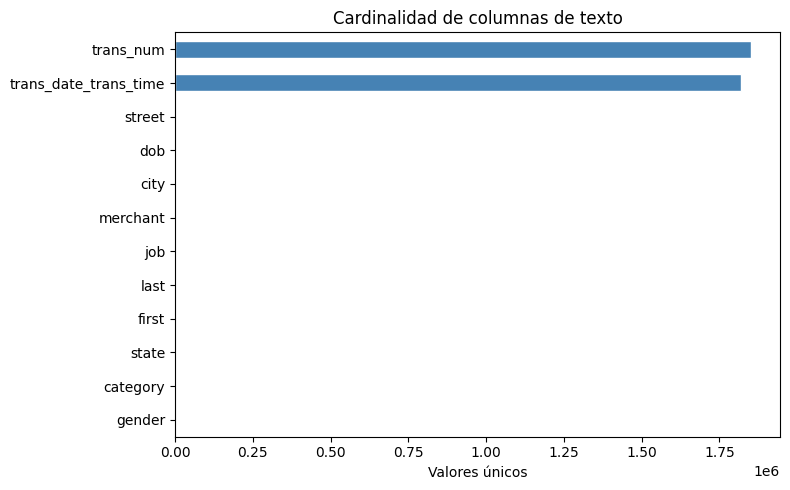

In [9]:
from src.eda import plot_text_analysis

plot_text_analysis(df)

La cardinalidad de cada columna justifica las decisiones de eliminación:

**`trans_num`:** 1,852,394 valores únicos, exactamente igual al número de filas. Identificador único por transacción. Se elimina.

**`trans_date_trans_time`:** 1,819,551 valores únicos. Su alta cardinalidad confirma que no puede usarse directamente como categórica. La información útil (hora, día de la semana) se extrae en el feature engineering y la columna original se descarta.

**`street`, `first`, `last`:** cardinalidades de 999, 355 y 486, consistentes con los 1,000 clientes del dataset. Son datos personales identificables sin señal predictiva. Se eliminan.

**`dob`:** 984 valores únicos, uno por cliente aproximadamente. No puede usarse como categórica ni como numérica directamente. Se transforma en la variable `edad` durante el feature engineering y luego se descarta.

**`merchant`:** 693 valores únicos, coherente con los 800 comerciantes del dataset. Cardinalidad demasiado alta para codificación directa. La variable `category` (14 valores) ya captura el tipo de negocio, que es la información relevante. Se elimina.

**`city` y `state`:** 906 y 51 valores únicos. La ubicación geográfica queda capturada con mayor precisión por las coordenadas, de las que se derivará `distancia`. Se eliminan.

**`job`:** 497 valores únicos, cardinalidad alta sin vínculo directo con el patrón de fraude. Se elimina.

**`gender`:** 2 valores. Su eliminación fue justificada en el EDA por diferencia de 0.09 puntos porcentuales en tasa de fraude entre géneros.

### Limpieza

In [10]:
from src.preprocessing import clean_data

df_clean = clean_data(df)
print(f"Columnas tras limpieza ({df_clean.shape[1]}): {list(df_clean.columns)}")

Columnas tras limpieza (10): ['trans_date_trans_time', 'category', 'amt', 'lat', 'long', 'city_pop', 'dob', 'merch_lat', 'merch_long', 'is_fraud']


### Feature Engineering

Se crean variables derivadas que capturan información estructurada a partir de columnas originales que no pueden usarse directamente como numéricas:

- **hora** y **dia_semana**: extraídos de `trans_date_trans_time`. El EDA mostró que la hora es la variable con mayor poder discriminativo del dataset (tasa de fraude 20-25 veces mayor en horario nocturno).
- **edad**: calculada a partir de `dob` usando como referencia el 2021-01-01 (día después al cierre del dataset). La edad del titular puede estar correlacionada con perfiles de comportamiento distintos.
- **distancia**: distancia en kilómetros entre la ubicación del titular (`lat`, `long`) y la del comercio (`merch_lat`, `merch_long`), calculada con la fórmula de Haversine. Una distancia inusualmente alta puede indicar que la tarjeta se está usando lejos de su titular.
- **`cat_*`**: codificación one-hot de la categoría del comercio (14 columnas binarias). El EDA mostró diferencias de hasta 10 veces en la tasa de fraude entre categorías.

Las columnas originales de las que se derivan estas features se descartan tras la transformación.

In [11]:
from src.preprocessing import feature_engineering

df_feat = feature_engineering(df_clean)
print(f"Columnas tras feature engineering ({df_feat.shape[1]}): {list(df_feat.columns)}")

Columnas tras feature engineering (23): ['amt', 'city_pop', 'is_fraud', 'hora', 'dia_semana', 'is_noche', 'log_amt', 'edad', 'distancia', 'cat_entertainment', 'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net', 'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets', 'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net', 'cat_shopping_pos', 'cat_travel']


### Escala y correlación de las features

Con el dataset ya limpio y transformado se analiza el rango de cada variable y las correlaciones entre ellas. El rango determina si las escalas son comparables entre sí o si se requiere normalización. Las correlaciones detectan si algún par de features es redundante.

Min, max y rango por variable numérica:
                     min          max        rango
city_pop           23.00 2,906,700.00 2,906,677.00
amt                 1.00    28,948.90    28,947.90
distancia           0.02       152.12       152.09
edad               15.00        96.00        81.00
hora                0.00        23.00        23.00
log_amt             0.69        10.27         9.58
dia_semana          0.00         6.00         6.00
is_noche            0.00         1.00         1.00
cat_entertainment   0.00         1.00         1.00
cat_food_dining     0.00         1.00         1.00
cat_gas_transport   0.00         1.00         1.00
cat_grocery_net     0.00         1.00         1.00
cat_grocery_pos     0.00         1.00         1.00
cat_health_fitness  0.00         1.00         1.00
cat_home            0.00         1.00         1.00
cat_kids_pets       0.00         1.00         1.00
cat_misc_net        0.00         1.00         1.00
cat_misc_pos        0.00         1.00     

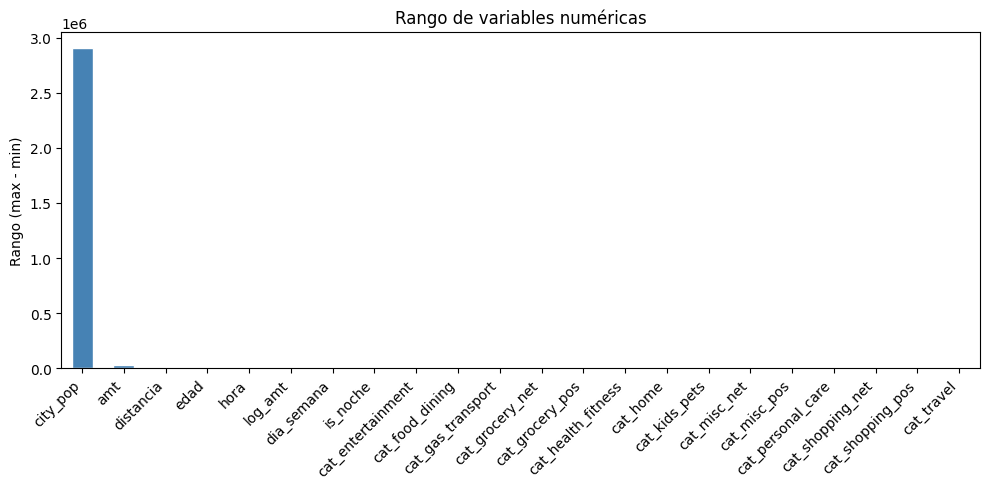

In [12]:
from src.eda import plot_ranges, plot_correlation_matrix

plot_ranges(df_feat.drop(columns=['is_fraud']))

Las escalas entre variables son radicalmente distintas: `city_pop` tiene un rango de casi 2.9 millones, `amt` de 28,948, `distancia` de 152 km, `edad` de 81 años, `hora` de 23 y `dia_semana` de 6. Las variables `cat_*` son binarias con rango 1.

Sin escalado, variables como `city_pop` dominarían los cálculos del modelo por magnitud, no por relevancia. El escalado con `StandardScaler` es necesario para que todas las features contribuyan en igualdad de condiciones.

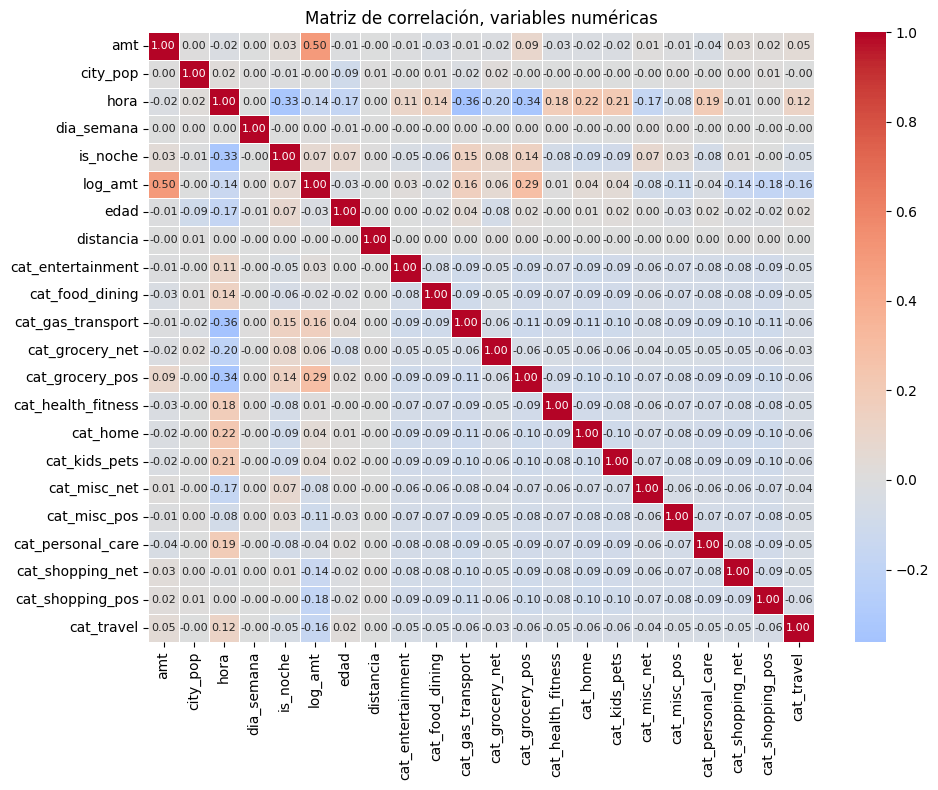

In [13]:
plot_correlation_matrix(df_feat)

Ningún par de features independientes supera una correlación absoluta de 0.40, lo que indica que no hay redundancia significativa entre las variables resultantes del preprocesamiento.

Las correlaciones más fuertes en valor absoluto involucran a `hora` con algunas categorías: -0.36 con `cat_gas_transport` y -0.34 con `cat_grocery_pos`. El signo negativo indica que esas categorías tienden a ocurrir en horario diurno (cuando `hora` es baja), lo cual refleja una relación real del dominio, no redundancia. Ambas variables aportan información distinta al modelo.

Las correlaciones negativas entre variables `cat_*` entre sí son esperadas y no representan un problema: son el resultado matemático de la codificación one-hot sobre una variable mutuamente excluyente.

`amt`, `distancia`, `city_pop`, `dia_semana` y `edad` muestran correlaciones cercanas a cero con todo lo demás, confirmando que cada una aporta una dimensión de información independiente.

### División train/validation/test y escalado

El conjunto se divide de forma estratificada en **60% train, 20% validation y 20% test** (`split_data_three_way`). El train retiene únicamente transacciones normales (`is_fraud == 0`), acorde al enfoque no supervisado. **Validation** se usa para calibrar umbrales (maximizar F1 sobre la curva Precision-Recall) y comparar candidatos; **test** queda reservado para las métricas finales de la sección 8.

El `StandardScaler` se ajusta exclusivamente sobre `X_train` y luego se aplica a train, val y test (`scale_splits`). Ajustarlo también sobre val o test introduciría data leakage.

In [14]:
import os
import numpy as np
import joblib
from src.preprocessing import split_data_three_way, scale_splits

X_train, X_val, X_test, y_train, y_val, y_test, contamination_rate = split_data_three_way(
    df_feat, val_size=0.2, test_size=0.2, random_state=42
)
X_train_sc, X_val_sc, X_test_sc, scaler = scale_splits(X_train, X_val, X_test)

print(f"Train (solo normales): {X_train_sc.shape}")
print(f"Val:  {X_val_sc.shape},  Fraudes en val:  {y_val.sum():,} ({y_val.mean()*100:.2f}%)")
print(f"Test: {X_test_sc.shape},  Fraudes en test: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print(f"Contaminación (dataset): {contamination_rate:.4f} ({contamination_rate*100:.2f}%)")
print(f"Fraudes en y_train → {y_train.sum()}")

Train (solo normales): (1105645, 22)
Val:  (370479, 22),  Fraudes en val:  1,930 (0.52%)
Test: (370479, 22),  Fraudes en test: 1,930 (0.52%)
Contaminación (dataset): 0.0052 (0.52%)
Fraudes en y_train → 0


## 5. Modelo 1 — Isolation Forest

Isolation Forest es un algoritmo de detección de anomalías basado en **aislamiento aleatorio**. La idea central es que los puntos anómalos son mucho más fáciles de aislar del resto de los datos que los puntos normales.

El algoritmo construye múltiples árboles de decisión aleatorios. En cada nodo elige aleatoriamente una variable y un punto de corte dentro de su rango, dividiendo los datos de forma recursiva hasta que cada punto queda aislado en su propia hoja. Lo que determina si una transacción es anómala es cuántos pasos se necesitaron para aislarla.

**Las transacciones normales** están agrupadas con otras similares, por lo que requieren muchas divisiones para quedar solas en una hoja. El camino hasta aislarlas es largo.

**Las transacciones anómalas** están lejos del grupo mayoritario, por lo que se aíslan en muy pocos pasos. El camino es corto.

La fórmula que lo define formalmente es:

$$s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}$$

Un score cercano a 1 indica que la transacción fue fácil de aislar y es probablemente anómala, mientras que un score cercano a 0.5 indica que se comporta como una transacción normal típica.

### Hiperparámetros principales

| Hiperparámetro | Valor usado | Descripción |
|---|---|---|
| `n_estimators` | 100 | Número de árboles del ensamble. Más árboles producen resultados más estables pero aumentan el tiempo de entrenamiento. |
| `contamination` | calculado dinámicamente | Proporción esperada de anomalías en los datos. Define el umbral interno del score que separa normal de anómalo. |
| `max_samples` | `"auto"` | Número de muestras que recibe cada árbol. Por defecto toma min(256, n_muestras). |
| `random_state` | 42 | Semilla aleatoria para garantizar la reproducibilidad de los resultados. |

### Entrenamiento

El modelo se entrena exclusivamente con transacciones normales. El algoritmo aprende cómo se distribuyen las transacciones legítimas sin ver ningún fraude, de forma que durante la evaluación pueda identificar las que se comportan de manera diferente a ese patrón aprendido.

La tasa de contaminación se calcula a partir del conjunto completo antes de filtrar solo las muestras normales. Esto garantiza que el umbral interno del modelo refleje la proporción real de fraude en los datos.

In [15]:
import numpy as np
from src.models import train_isolation_forest, predict_isolation_forest, predict_isolation_forest_with_refs
from src.evaluation import get_metrics, plot_confusion_matrix, plot_roc_curve, plot_score_distribution, find_optimal_threshold, plot_precision_recall_curve

print(f"Tasa de fraude en dataset: {contamination_rate:.4f} ({contamination_rate*100:.2f}%)")

iforest = train_isolation_forest(X_train_sc, contamination=contamination_rate, random_state=42)

# Normalización de scores con referencia fija de validation
_, if_scores_val, if_ref_min, if_ref_max = predict_isolation_forest_with_refs(iforest, X_val_sc)
if_labels, if_scores = predict_isolation_forest(iforest, X_test_sc, ref_min=if_ref_min, ref_max=if_ref_max)
print(f"Transacciones marcadas como anomalas : {if_labels.sum():,}  ({if_labels.mean()*100:.2f}%)")
print(f"Fraudes reales en test               : {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")

Tasa de fraude en dataset: 0.0052 (0.52%)
Transacciones marcadas como anomalas : 2,329  (0.63%)
Fraudes reales en test               : 1,930  (0.52%)


El porcentaje de transacciones marcadas como anómalas sobre el conjunto de prueba debe ser aproximadamente igual a la tasa de contaminación configurada, ya que ese parámetro es el que determina el umbral interno del score.

### Evaluación

La **accuracy** no es una métrica confiable en conjuntos de datos tan desbalanceados como este. Un modelo que siempre predice "Normal" alcanzaría un 99.48% de exactitud sin detectar ni un solo fraude. Por eso el análisis se centra en métricas que reflejan mejor el rendimiento sobre la clase minoritaria.

La **precision** mide qué fracción de las transacciones marcadas como anómalas son fraudes reales. Una precision baja significa muchas falsas alarmas, lo que en la práctica genera trabajo innecesario para los analistas.

El **recall** mide qué fracción de todos los fraudes reales logró detectar el modelo. Un recall bajo significa fraudes que pasaron sin ser detectados, que es el error más costoso en este tipo de problema.

El **F1** es la media armónica entre precision y recall. Penaliza cuando una de las dos métricas es muy baja y resume en un solo número el equilibrio entre ambas.

El **AUC-ROC** evalúa la calidad del score continuo de anomalía para todos los umbrales posibles a la vez, con independencia del valor de contaminación configurado durante el entrenamiento.

In [16]:
if_metrics = get_metrics(y_test.values, if_labels, if_scores, model_name="Isolation Forest")


  Isolation Forest
  Accuracy : 0.9913
  Precision: 0.2211
  Recall   : 0.2668
  F1       : 0.2418
  AUC-ROC  : 0.8996
  PR-AUC   : 0.1258



### Matriz de Confusión

La matriz de confusión muestra los cuatro resultados posibles de clasificación. Los **Verdaderos Positivos** son fraudes detectados correctamente. Los **Falsos Negativos** son fraudes que el modelo no detectó. Los **Falsos Positivos** son transacciones normales marcadas erróneamente como anómalas. Los **Verdaderos Negativos** son transacciones normales correctamente identificadas.

Dado el desbalance extremo del conjunto de datos, un número elevado de Falsos Positivos puede representar una proporción pequeña sobre el total de transacciones normales. Lo más importante en este contexto es minimizar los Falsos Negativos, es decir, reducir la cantidad de fraudes que el modelo no detecta.

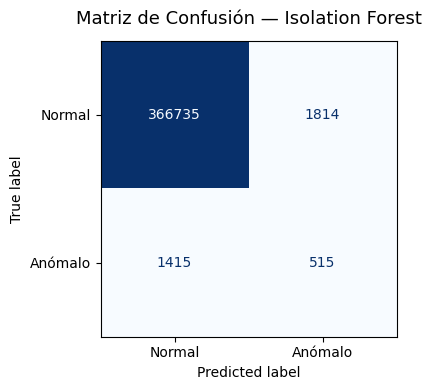

In [17]:
plot_confusion_matrix(y_test.values, if_labels, model_name="Isolation Forest")

### Curva ROC

La curva ROC grafica el recall frente a la tasa de falsos positivos para todos los umbrales posibles del score de anomalía. El **AUC** resume esa curva en un solo número: 0.5 equivale a una clasificación completamente aleatoria y 1.0 a una separación perfecta entre fraudes y transacciones normales.

A diferencia de las métricas que dependen de un umbral fijo, el AUC evalúa la calidad del score continuo en su totalidad y no se ve afectado por el valor de contaminación configurado durante el entrenamiento.

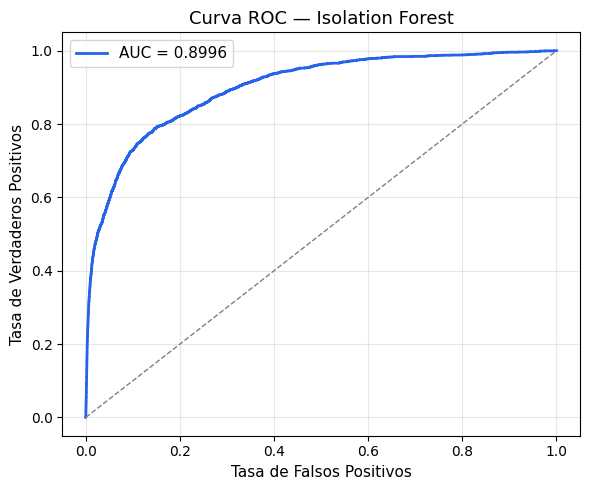

In [18]:
plot_roc_curve(y_test.values, if_scores, model_name="Isolation Forest")

### Distribución del Score de Anomalía

El histograma muestra cómo se distribuye el score de anomalía para cada clase real, donde 0 representa el comportamiento más normal y 1 el más anómalo. Una separación clara entre las dos curvas indica que el modelo asigna scores sistemáticamente más altos a los fraudes.

El solapamiento entre ambas distribuciones refleja cuántos fraudes tienen scores similares a los de transacciones normales, lo que evidencia la dificultad del problema para el algoritmo.

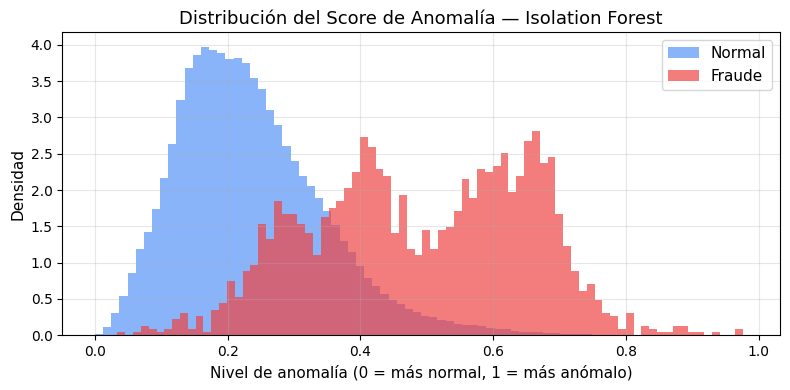

In [19]:
plot_score_distribution(if_scores, y_test.values, model_name="Isolation Forest")

### Umbral Óptimo

El parámetro `contamination` fija un corte que marca exactamente ese porcentaje del conjunto de prueba como anómalo, sin tener en cuenta cómo se distribuyen realmente los scores. Esto puede limitar el recall cuando la distribución real de fraudes no coincide con la tasa configurada.

Una alternativa es buscar el corte que maximiza el F1 directamente sobre la curva Precision-Recall del **conjunto de validación**. Ese umbral se aplica luego a test para reportar métricas finales sin filtrar información del test durante la calibración.

Umbral calibrado en val (max F1): 0.6078


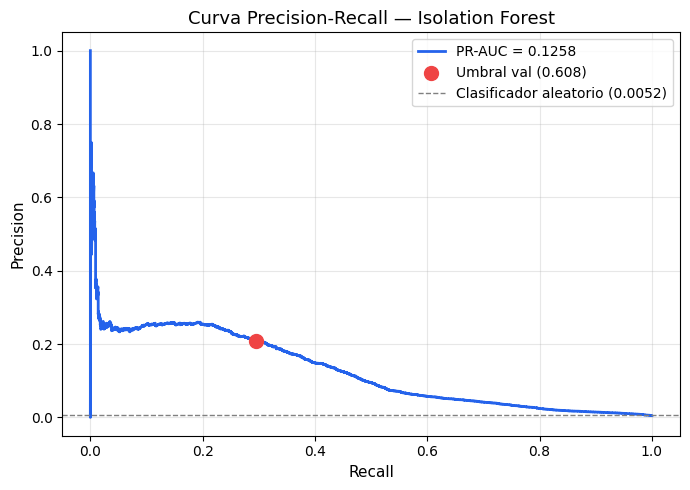


  Isolation Forest (umbral val → test)
  Accuracy : 0.9905
  Precision: 0.2092
  Recall   : 0.2943
  F1       : 0.2446
  AUC-ROC  : 0.8996
  PR-AUC   : 0.1258



In [20]:
best_thresh, _ = find_optimal_threshold(y_val.values, if_scores_val)
if_labels_opt = (if_scores >= best_thresh).astype(int)
print(f"Umbral calibrado en val (max F1): {best_thresh:.4f}")

plot_precision_recall_curve(y_test.values, if_scores, threshold=best_thresh, model_name="Isolation Forest")

if_metrics_opt = get_metrics(y_test.values, if_labels_opt, if_scores, model_name="Isolation Forest (umbral val → test)")

El solapamiento visible en la distribución refleja una dificultad propia del problema: el fraude en este conjunto de datos se caracteriza por combinaciones específicas de variables como montos, horarios y categorías, que no siempre producen transacciones fáciles de aislar individualmente.

Isolation Forest detecta transacciones que son estadísticamente poco comunes en el conjunto general. Esta limitación motiva el uso complementario de LOF (sección 6) y del Autoencoder (sección 7), que capturan anomalías locales y por reconstrucción. La comparativa sistemática con tuning y selección de ganadores se cierra en la sección 8.

## 6. Modelo 2 — Local Outlier Factor (LOF)

Local Outlier Factor (LOF) es un algoritmo de detección de anomalías basado en **densidad local**. A diferencia de Isolation Forest, que evalúa qué tan fácil es aislar un punto del conjunto completo, LOF compara la densidad de cada punto con la de sus vecinos más cercanos.

La idea central es que un punto normal está rodeado de puntos con una densidad similar a la suya. Un punto anómalo, en cambio, tiene una densidad mucho más baja que la de sus vecinos: se encuentra en una región dispersa rodeada de un vecindario más compacto.

El score LOF de un punto $x$ se define como:

$$\text{LOF}_k(x) = \frac{\overline{\text{lrd}_k(x')}}{\text{lrd}_k(x)}, \quad x' \in N_k(x)$$

donde $\text{lrd}_k(x)$ es la **densidad de alcanzabilidad local** de $x$ respecto a sus $k$ vecinos más cercanos $N_k(x)$. Un LOF $\approx 1$ indica que el punto está en una región de densidad similar a sus vecinos (comportamiento normal). Un LOF $\gg 1$ indica que el punto está en una región mucho menos densa que su vecindario (comportamiento anómalo).

Esta perspectiva **local** complementa la perspectiva **global** de Isolation Forest: mientras IF detecta puntos que se alejan del conjunto completo, LOF detecta puntos que son inusuales dentro de su propio entorno. En el contexto de fraude, esto permite identificar transacciones que no son atípicas en el dataset global pero sí son raras comparadas con transacciones similares cercanas.

Para que LOF pueda evaluar transacciones nuevas sin necesidad de reentrenar, se utiliza `novelty=True`. Este modo almacena el conjunto de entrenamiento y lo usa como referencia para calcular la densidad de cualquier punto nuevo a través de `predict()` y `decision_function()`. Sin este parámetro, LOF solo puede evaluar los puntos sobre los que fue entrenado.

El modelo requiere que las variables estén en la misma escala para que los cálculos de distancia sean comparables. El `StandardScaler` aplicado en la sección 4f garantiza esta condición.

### Hiperparámetros principales

| Hiperparámetro | Valor usado | Descripción |
|---|---|---|
| `n_neighbors` | 20 | Número de vecinos para calcular la densidad local. Valores pequeños hacen el modelo sensible a variaciones locales; valores grandes suavizan la detección. |
| `contamination` | calculado dinámicamente | Proporción esperada de anomalías. Define el umbral del score que separa normal de anómalo. |
| `novelty` | `True` | Habilita la detección sobre datos nuevos no vistos durante el entrenamiento. |
| `n_jobs` | -1 | Usa todos los núcleos disponibles para paralelizar los cálculos de vecinos. |

### Entrenamiento

El modelo se entrena exclusivamente con transacciones normales, siguiendo el mismo enfoque no supervisado que Isolation Forest. LOF aprende la estructura de densidad del comportamiento legítimo y, durante la evaluación, identifica las transacciones que se desvían de esa estructura.

La tasa de contaminación se calcula sobre el conjunto completo antes del filtrado, de la misma forma que en la sección 5.

**Nota:** LOF con `novelty=True` almacena todos los puntos de entrenamiento para calcular densidades durante la inferencia. Con 1.47 millones de transacciones esto puede tomar entre 10 y 30 minutos dependiendo del hardware disponible.

In [21]:
from src.models import train_lof, predict_lof, predict_lof_with_refs

print(f"Tasa de fraude en dataset: {contamination_rate:.4f} ({contamination_rate*100:.2f}%)")

# Nota: el ajuste puede tardar varios minutos por el tamaño del conjunto de entrenamiento
lof = train_lof(X_train_sc, n_neighbors=20, contamination=contamination_rate)

_, lof_scores_val, lof_ref_min, lof_ref_max = predict_lof_with_refs(lof, X_val_sc)
lof_labels, lof_scores = predict_lof(lof, X_test_sc, ref_min=lof_ref_min, ref_max=lof_ref_max)
print(f"Transacciones marcadas como anomalas : {lof_labels.sum():,}  ({lof_labels.mean()*100:.2f}%)")
print(f"Fraudes reales en test               : {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")

Tasa de fraude en dataset: 0.0052 (0.52%)


C:\Users\Usuario\Documents\UNA\2026\Semestre-1\IA\proyecto\AnomalyDetection\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\Usuario\Documents\UNA\2026\Semestre-1\IA\proyecto\AnomalyDetection\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\Usuario\Documents\UNA\2026\Semestre-1\IA\proyecto\AnomalyDetection\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\Usuario\Documents\UNA\2026\Semestre-1\IA\proyecto\AnomalyDetection\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
 

Transacciones marcadas como anomalas : 2,736  (0.74%)
Fraudes reales en test               : 1,930  (0.52%)


### Evaluación

Se calculan las mismas métricas que en la sección 5. La **accuracy** sigue siendo una métrica engañosa dado el desbalance extremo, por lo que el análisis se centra en precision, recall, F1 y AUC-ROC.

In [22]:
lof_metrics = get_metrics(y_test.values, lof_labels, lof_scores, model_name="Local Outlier Factor")


  Local Outlier Factor
  Accuracy : 0.9919
  Precision: 0.3030
  Recall   : 0.4295
  F1       : 0.3553
  AUC-ROC  : 0.8354
  PR-AUC   : 0.3915



### Matriz de Confusión

Los Verdaderos Positivos son fraudes detectados, los Falsos Negativos son fraudes no detectados (el error más costoso en este dominio) y los Falsos Positivos son transacciones normales marcadas erróneamente.

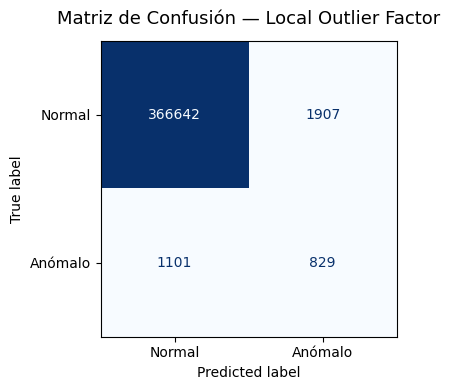

In [23]:
plot_confusion_matrix(y_test.values, lof_labels, model_name="Local Outlier Factor")

### Curva ROC

La curva ROC evalúa la calidad del score continuo para todos los umbrales posibles. El AUC sintetiza esa calidad en un único número, independiente del valor de contaminación configurado.

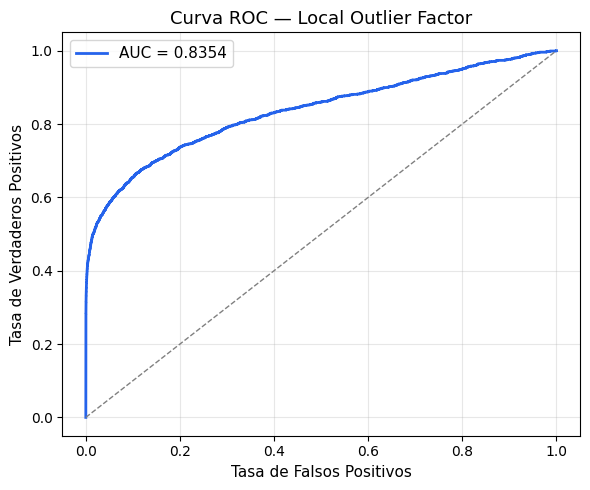

In [24]:
plot_roc_curve(y_test.values, lof_scores, model_name="Local Outlier Factor")

### Distribución del Score de Anomalía

El histograma muestra la distribución del score para transacciones normales y fraudulentas. Una buena separación entre las dos curvas indica que LOF asigna sistemáticamente scores más altos a los fraudes. El solapamiento revela los casos ambiguos donde el comportamiento fraudulento es difícil de distinguir del normal.

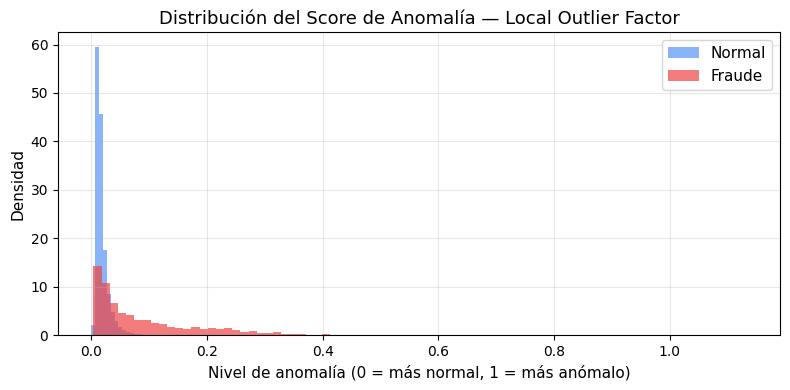

In [25]:
plot_score_distribution(lof_scores, y_test.values, model_name="Local Outlier Factor")

### Umbral Óptimo

Al igual que con Isolation Forest, el umbral fijo basado en la tasa de contaminación puede no ser el óptimo para maximizar el F1. Se busca el umbral que maximiza F1 en **validación** y se evalúa en test.

Umbral calibrado en val (max F1): 0.1042


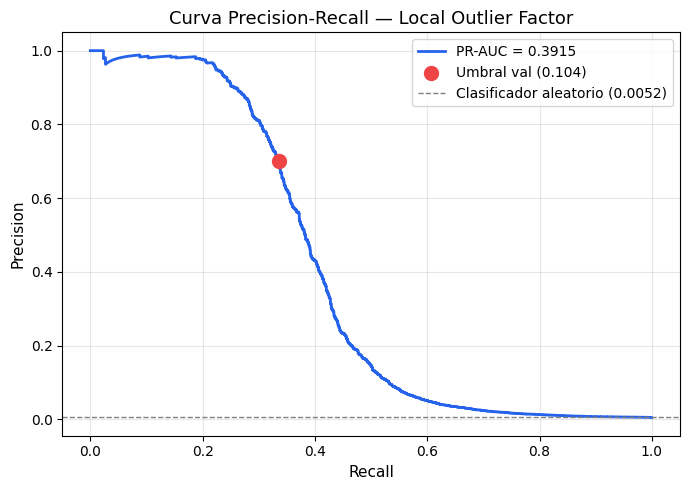


  Local Outlier Factor (umbral val → test)
  Accuracy : 0.9958
  Precision: 0.6998
  Recall   : 0.3358
  F1       : 0.4538
  AUC-ROC  : 0.8354
  PR-AUC   : 0.3915



In [26]:
best_thresh_lof, _ = find_optimal_threshold(y_val.values, lof_scores_val)
lof_labels_opt = (lof_scores >= best_thresh_lof).astype(int)
print(f"Umbral calibrado en val (max F1): {best_thresh_lof:.4f}")

plot_precision_recall_curve(y_test.values, lof_scores, threshold=best_thresh_lof, model_name="Local Outlier Factor")

lof_metrics_opt = get_metrics(y_test.values, lof_labels_opt, lof_scores, model_name="Local Outlier Factor (umbral val → test)")

El comportamiento de LOF en este dataset refleja su naturaleza local: puede detectar fraudes que son inusuales dentro de su contexto de transacciones similares, pero puede pasar por alto fraudes que, aunque atípicos globalmente, tienen vecinos con densidad comparable.

La sección 7 entrena un Autoencoder como candidato de red neuronal. La sección 8 compara LOF e IF con otros candidatos ML (One-Class SVM), variantes de autoencoder y un ensemble IF+LOF.

## 7. Modelo 3 — Autoencoder (Red Neuronal)

Un Autoencoder es una red neuronal que aprende a **comprimir** y luego **reconstruir** su propia entrada. El objetivo de entrenamiento no es predecir una etiqueta externa, sino reproducir lo más fielmente posible el dato original después de pasarlo por un cuello de botella.

La red se divide en dos partes:

- **Encoder:** reduce progresivamente la dimensión de la entrada (20 → 16 → 8) hasta llegar al cuello de botella. En ese punto, el modelo ha tenido que resumir la transacción en sus rasgos más esenciales.
- **Decoder:** reconstruye la entrada original a partir de esa representación comprimida (8 → 16 → 20).

Cuando se entrena solo con transacciones normales, el modelo aprende a reconstruir bien el comportamiento legítimo. Al evaluar una transacción nueva, el **error de reconstrucción** (MSE entre la entrada y la salida) indica cuán diferente es de lo normal: un error alto señala una transacción que el modelo no sabe cómo reconstruir, es decir, una anomalía.

$$\text{score}(x) = \frac{1}{d} \sum_{i=1}^{d} (x_i - \hat{x}_i)^2$$

donde $\hat{x}$ es la reconstrucción de $x$ y $d$ es el número de features. Este score se normaliza a [0, 1] para comparabilidad con Isolation Forest y LOF.

La activación `linear` en la capa de salida es la opción correcta cuando los datos están estandarizados con `StandardScaler`: los valores pueden ser negativos y no están acotados entre 0 y 1, por lo que activaciones como `sigmoid` distorsionarían la reconstrucción.

`EarlyStopping` monitorea el loss de validación y detiene el entrenamiento cuando deja de mejorar durante `patience` épocas consecutivas. Esto evita que el modelo memorice los datos de entrenamiento (sobreajuste) y garantiza que el modelo guardado sea el de mejor generalización.

### Hiperparámetros

| Hiperparámetro | Valor | Descripción |
|---|---|---|
| `encoding_dim` | 8 | Dimensión del cuello de botella. Con 20 features, representa una compresión de 2.5× que obliga al modelo a aprender las relaciones entre variables. |
| `epochs` | 50 (máx) | Número máximo de épocas. EarlyStopping puede detener el entrenamiento antes si la validación deja de mejorar. |
| `batch_size` | 512 | Número de muestras por actualización de pesos. Lotes más grandes producen gradientes más estables con conjuntos grandes. |
| `validation_split` | 0.10 | Fracción del conjunto de entrenamiento reservada para monitorear el sobreajuste durante el entrenamiento. |
| `patience` | 5 | Épocas sin mejora en val_loss antes de detener el entrenamiento y restaurar los mejores pesos. |
| `optimizer` | Adam | Algoritmo de optimización con tasa de aprendizaje adaptativa. Converge más rápido que SGD estándar. |
| `loss` | MSE | Error cuadrático medio entre entrada y reconstrucción. Es el score de anomalía antes de normalizar. |

### Entrenamiento

El Autoencoder se entrena pasando `X_train_sc` como entrada **y** como salida objetivo: la red aprende a reconstruir las mismas transacciones que recibe. Solo ve transacciones normales durante el entrenamiento, igual que Isolation Forest y LOF.

En esta sección se entrena la variante **vanilla** como referencia pedagógica. El umbral de detección se **calibra en validation** (`calibrate_ae_threshold_on_val`) maximizando F1, no en train ni en test. La sección 8 compara además un **Denoising Autoencoder** con bottleneck más agresivo.

In [27]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suprimir logs de TensorFlow

from src.models import train_autoencoder, predict_autoencoder, predict_autoencoder_with_refs, calibrate_ae_threshold_on_val
from src.evaluation import plot_learning_curve

print(f"Tasa de fraude en dataset: {contamination_rate:.4f} ({contamination_rate*100:.2f}%)")

autoencoder, ae_history, _ = train_autoencoder(
    X_train_sc,
    y_train,
    encoding_dim=8,
    epochs=50,
    batch_size=512,
    contamination=contamination_rate,
    denoising=False,
)

epochs_run = len(ae_history.history['loss'])
print(f"Epocas ejecutadas: {epochs_run}")
print(f"Loss final (train): {ae_history.history['loss'][-1]:.6f}")
print(f"Loss final (val)  : {ae_history.history['val_loss'][-1]:.6f}")

ae_threshold = calibrate_ae_threshold_on_val(autoencoder, X_val_sc, y_val)
_, ae_scores_val, ae_ref_min, ae_ref_max = predict_autoencoder_with_refs(autoencoder, X_val_sc, ae_threshold)
ae_labels, ae_scores = predict_autoencoder(
    autoencoder, X_test_sc, ae_threshold, ref_min=ae_ref_min, ref_max=ae_ref_max
)
print(f"Umbral MSE calibrado en val          : {ae_threshold:.6f}")
print(f"Transacciones marcadas como anomalas: {ae_labels.sum():,}  ({ae_labels.mean()*100:.2f}%)")
print(f"Fraudes reales en test              : {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")

Tasa de fraude en dataset: 0.0052 (0.52%)
Epocas ejecutadas: 24
Loss final (train): 0.198772
Loss final (val)  : 0.202248
Umbral MSE calibrado en val          : 0.401327
Transacciones marcadas como anomalas: 18,023  (4.86%)
Fraudes reales en test              : 1,930  (0.52%)


### Curva de Aprendizaje

La curva de aprendizaje muestra cómo evoluciona el loss (MSE) en cada época, tanto en el conjunto de entrenamiento como en el de validación.

Lo que se busca es una curva donde ambas líneas desciendan y converjan hacia valores similares. Si el loss de entrenamiento sigue bajando pero el de validación se estabiliza o sube, el modelo está sobreajustando: está memorizando los datos de entrenamiento en lugar de aprender patrones generales. El `EarlyStopping` con `restore_best_weights=True` detiene el entrenamiento justo en el punto de mejor generalización y restaura los pesos de esa época.

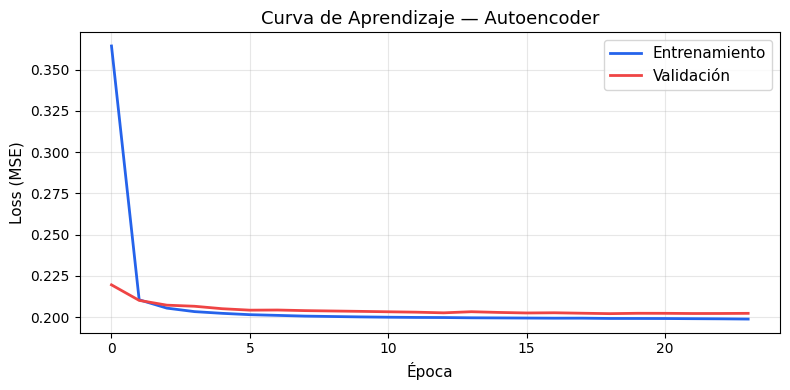

In [28]:
plot_learning_curve(ae_history, model_name="Autoencoder")

### Evaluación

Se calculan las mismas métricas que en las secciones 5 y 6. La accuracy sigue siendo engañosa por el desbalance extremo. El análisis se centra en precision, recall, F1 y AUC-ROC.

In [29]:
ae_metrics = get_metrics(y_test.values, ae_labels, ae_scores, model_name="Autoencoder")


  Autoencoder
  Accuracy : 0.9487
  Precision: 0.0264
  Recall   : 0.2466
  F1       : 0.0477
  AUC-ROC  : 0.7301
  PR-AUC   : 0.0166



### Matriz de Confusión

Muestra los cuatro resultados posibles: fraudes detectados (Verdaderos Positivos), fraudes no detectados (Falsos Negativos), transacciones normales marcadas erróneamente (Falsos Positivos) y transacciones normales correctas (Verdaderos Negativos). El objetivo principal es minimizar los Falsos Negativos.

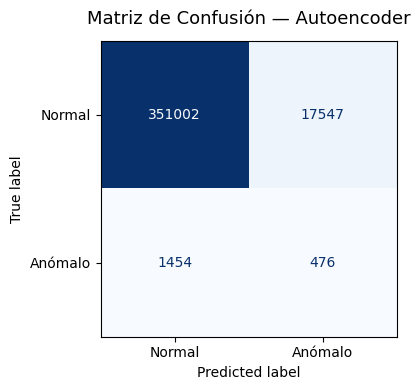

In [30]:
plot_confusion_matrix(y_test.values, ae_labels, model_name="Autoencoder")

### Curva ROC

Evalúa la calidad del score continuo de error de reconstrucción para todos los umbrales posibles. El AUC cuantifica esa calidad con independencia del umbral fijado durante el entrenamiento.

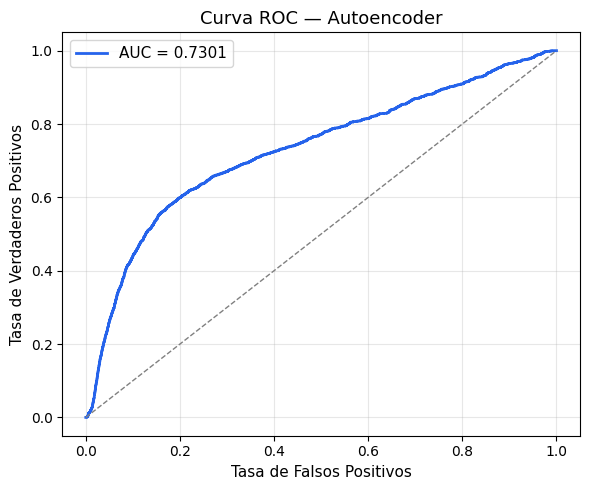

In [31]:
plot_roc_curve(y_test.values, ae_scores, model_name="Autoencoder")

### Distribución del Score de Anomalía

El histograma muestra cómo se distribuye el error de reconstrucción normalizado para transacciones normales y fraudulentas. Una buena separación entre las dos curvas indica que el Autoencoder reconstruye significativamente peor las transacciones fraudulentas, lo que confirma que aprendió el patrón del comportamiento legítimo.

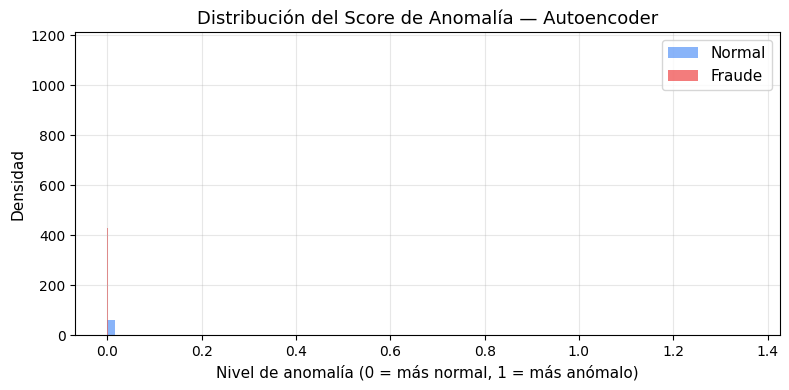

In [32]:
plot_score_distribution(ae_scores, y_test.values, model_name="Autoencoder")

### Umbral Óptimo

El umbral calibrado en validation puede refinarse escaneando la curva Precision-Recall en **val** (scores normalizados) y aplicando el corte resultante a test, igual que en las secciones 5 y 6.

Umbral score calibrado en val (max F1): 0.0011


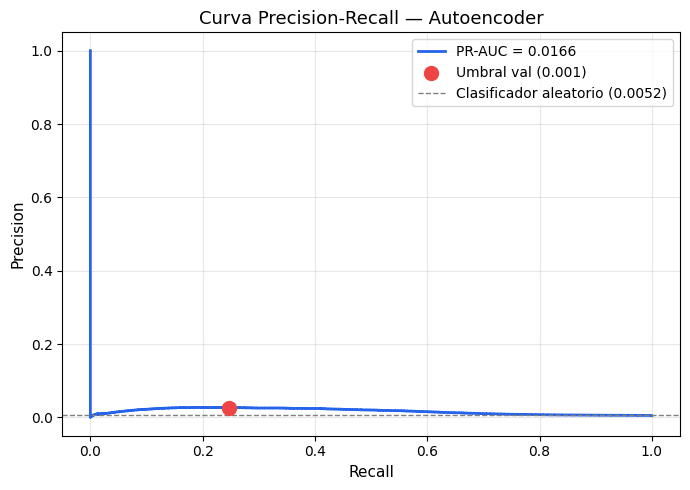


  Autoencoder (umbral val → test)
  Accuracy : 0.9487
  Precision: 0.0264
  Recall   : 0.2466
  F1       : 0.0477
  AUC-ROC  : 0.7301
  PR-AUC   : 0.0166



In [33]:
best_thresh_ae, _ = find_optimal_threshold(y_val.values, ae_scores_val)
ae_labels_opt = (ae_scores >= best_thresh_ae).astype(int)
print(f"Umbral score calibrado en val (max F1): {best_thresh_ae:.4f}")

plot_precision_recall_curve(y_test.values, ae_scores, threshold=best_thresh_ae, model_name="Autoencoder")

ae_metrics_opt = get_metrics(y_test.values, ae_labels_opt, ae_scores, model_name="Autoencoder (umbral val → test)")

Con el Autoencoder vanilla entrenado quedan ilustrados los tres enfoques principales del proyecto. La **sección 8** ejecuta un tuning sistemático (IF, LOF, One-Class SVM; AE vanilla vs Denoising AE), selecciona ganadores por familia ML/NL y evalúa un ensemble IF+LOF.

- **Isolation Forest** (sección 5): anomalías globales por aislamiento.
- **LOF** (sección 6): anomalías locales por densidad.
- **Autoencoder** (sección 7): anomalías por error de reconstrucción.

Las métricas definitivas y la decisión de modelo ganador se reportan en la sección 8 sobre **test**, con umbrales calibrados en **validation**.

## 8. Evaluación Comparativa

Esta sección cierra el entregable con una **comparativa sistemática**:

1. **Tuning ML** (`tune_ml_models`): Isolation Forest (varias `contamination`), LOF (varios `k`), One-Class SVM (varios `nu`).
2. **Tuning NL** (`tune_nl_models`): Autoencoder vanilla vs Denoising Autoencoder.
3. **Ensemble** IF+LOF (promedio de scores normalizados).

En todos los casos el **umbral se calibra en validation** (max F1 sobre la curva PR). Las métricas finales — incluyendo **PR-AUC** — se reportan en **test**. El ganador ML se elige por F1 en test (desempate PR-AUC); el ganador NL por F1 (desempate AUC-ROC).

In [ ]:
from src.tuning import tune_ml_models, tune_nl_models, evaluate_ensemble
from src.evaluation import compare_models, pick_winner
from src.models import (
    train_isolation_forest,
    predict_isolation_forest_with_refs,
    train_lof,
    predict_lof_with_refs,
)

X_tr = X_train_sc.values
X_va = X_val_sc.values
X_te = X_test_sc.values
y_va = y_val.values
y_te = y_test.values

print("=== Tuning candidatos ML (umbral en val, métricas en test) ===")
ml_results, ml_cfg = tune_ml_models(X_tr, X_va, X_te, y_va, y_te, contamination_rate)
ml_winner = ml_cfg["ml_winner"]
print(f"Ganador ML: {ml_winner}")

ml_table = {
    k: {kk: v for kk, v in m.items() if kk in ("modelo", "accuracy", "precision", "recall", "f1", "auc_roc", "pr_auc")}
    for k, m in ml_results.items()
}
compare_models(ml_table, title="Candidatos ML — test con umbral calibrado en val")

In [ ]:
# Comparativa con umbral óptimo por F1
print("=== Tuning candidatos NL ===")
nl_results, nl_cfg = tune_nl_models(
    X_tr, y_train.values, X_va, y_va, X_te, y_te, contamination_rate
)
nl_winner = nl_cfg["nl_winner"]
print(f"Ganador NL: {nl_winner}")

nl_table = {
    k: {kk: v for kk, v in m.items() if kk in ("modelo", "accuracy", "precision", "recall", "f1", "auc_roc", "pr_auc")}
    for k, m in nl_results.items()
}
compare_models(nl_table, title="Candidatos NL — test con umbral calibrado en val")

print("\n=== Ensemble IF + LOF ===")
if_model = train_isolation_forest(X_tr, contamination=contamination_rate)
lof_model = train_lof(X_tr, n_neighbors=20, contamination=contamination_rate)
_, if_va, r0, r1 = predict_isolation_forest_with_refs(if_model, X_va)
_, if_te, _, _ = predict_isolation_forest_with_refs(if_model, X_te, ref_min=r0, ref_max=r1)
_, lof_va, r0, r1 = predict_lof_with_refs(lof_model, X_va)
_, lof_te, _, _ = predict_lof_with_refs(lof_model, X_te, ref_min=r0, ref_max=r1)

ens_metrics = evaluate_ensemble(
    {},
    y_va,
    {"if": if_va, "lof": lof_va},
    y_te,
    {"if": if_te, "lof": lof_te},
)

section8_winners = {
    ml_winner: {k: ml_cfg["ml_metrics"][k] for k in ("modelo", "accuracy", "precision", "recall", "f1", "auc_roc", "pr_auc")},
    nl_winner: {k: nl_cfg["nl_metrics"][k] for k in ("modelo", "accuracy", "precision", "recall", "f1", "auc_roc", "pr_auc")},
    "Ensemble IF+LOF": ens_metrics,
}
compare_models(section8_winners, title="Ganadores ML vs NL vs Ensemble (test, umbral val)")

### Análisis comparativo


## 9. Sistema Interactivo

## 10. Análisis Crítico

## 11. Conclusiones